In [1]:
import numpy as np
import matplotlib.pyplot as plt
import hera_sim
from hera_sim import Simulator

In [2]:
from pyuvdata import UVData

In [3]:
from uvtools.plot import labeled_waterfall

In [6]:
def waterfall(sim, antpairpol=(0,1,"xx"), figsize=(6,3.5), dpi=200, title=None):
    """Convenient plotting function to show amp/phase."""
    fig, (ax1, ax2) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=figsize,
        dpi=dpi,
    )
    fig, ax1 = labeled_waterfall(
        sim.data,
        antpairpol=antpairpol,
        mode="log",
        ax=ax1,
        set_title=title,
    )
    ax1.set_xlabel(None)
    ax1.set_xticklabels(['' for tick in ax1.get_xticks()])
    fig, ax2 = labeled_waterfall(
        sim.data,
        antpairpol=antpairpol,
        mode="phs",
        ax=ax2,
        set_title=False,
    )
    return fig

In [7]:
UV = UVData()

#Foregrounds + EoR signal
UV.read(filename='zen.2458098.26719.sum.true.uvh5')

Telescope RIMEz calculation is not in known_telescopes.
Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 1.2720524896595843e-11, largest imaginary/real ratio was 1.5538135078853231e-15.


In [8]:
sim = Simulator(data=UV.copy())
hera_sim.defaults.set("h1c")

Range -1.1862217209495198 1.6707010450469697
Range -3.141592653589793 3.141592653589793


FixedFormatter should only be used together with FixedLocator


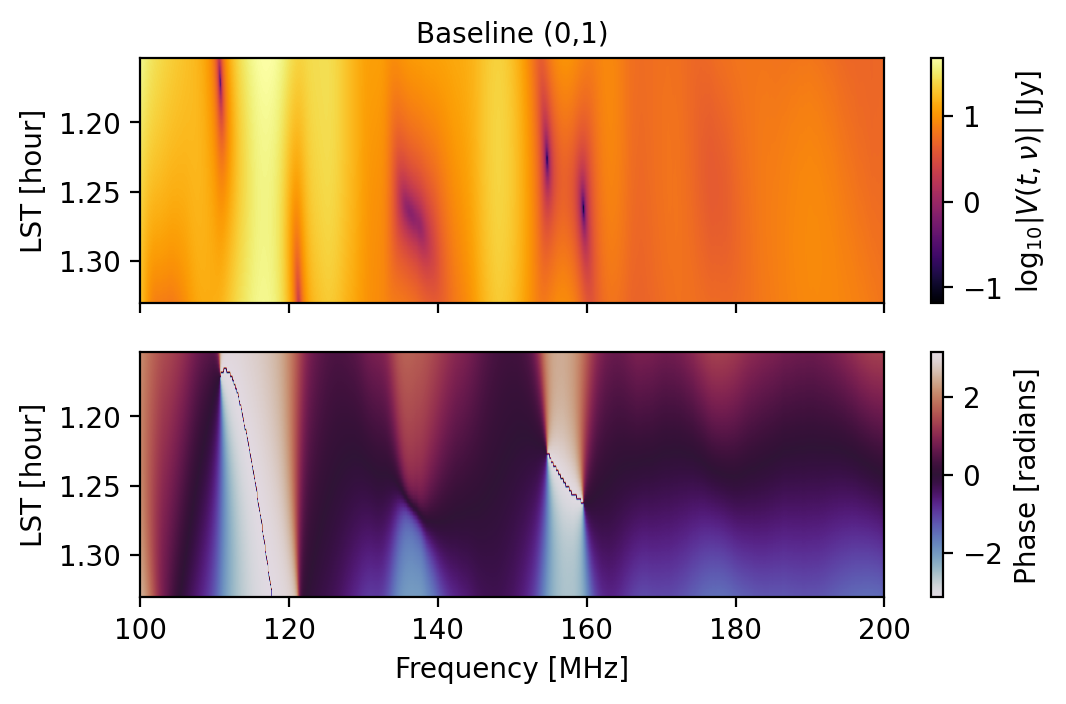

In [9]:
#Plot true data
fig1 = waterfall(sim, antpairpol=(0,1,"xx"), title="Baseline (0,1)")

### Add Systematics

In [10]:
#Gains
sim.add(component="gains",seed=1585957365)

In [11]:
#10 coupling peaks with randomisation
sim.add(component="CrossCouplingSpectrum", n_copies=10,
            amp_range=(-4,-6), dly_range=(900,1300), phs_range=(-np.pi,np.pi),
                amp_jitter=0.01, dly_jitter=20, seed=1585964131, symmetrize=True)

You are adding visibilities to a data array *after* multiplicative effects have been introduced.


In [12]:
#Reflection spectrum/20 subreflections
sim.add(component="reflection_spectrum", n_copies=20,
            amp_range=(-3,-4), dly_range=(200,1000), phs_range=(-np.pi,np.pi), 
            amp_jitter=0.01, dly_jitter=30, seed=2440572501)

In [13]:
#2 high-amplitude reflections
sim.add(component="reflections",amp=0.003,amp_jitter=0.01,dly=200,dly_jitter=10,seed=2440572505)
sim.add(component="reflections",amp=0.0008,amp_jitter=0.01,dly=1200,dly_jitter=30,seed=2440572506)

In [14]:
#Save corrupted data
#sim.write('zen.2458098.26719.sum.corrupt.uvh5', save_format="uvh5", fix_autos=True, clobber=True)

Range -5.4761420239857515 -1.0222679498976004
Range -3.141592653589793 3.141592653589793


FixedFormatter should only be used together with FixedLocator


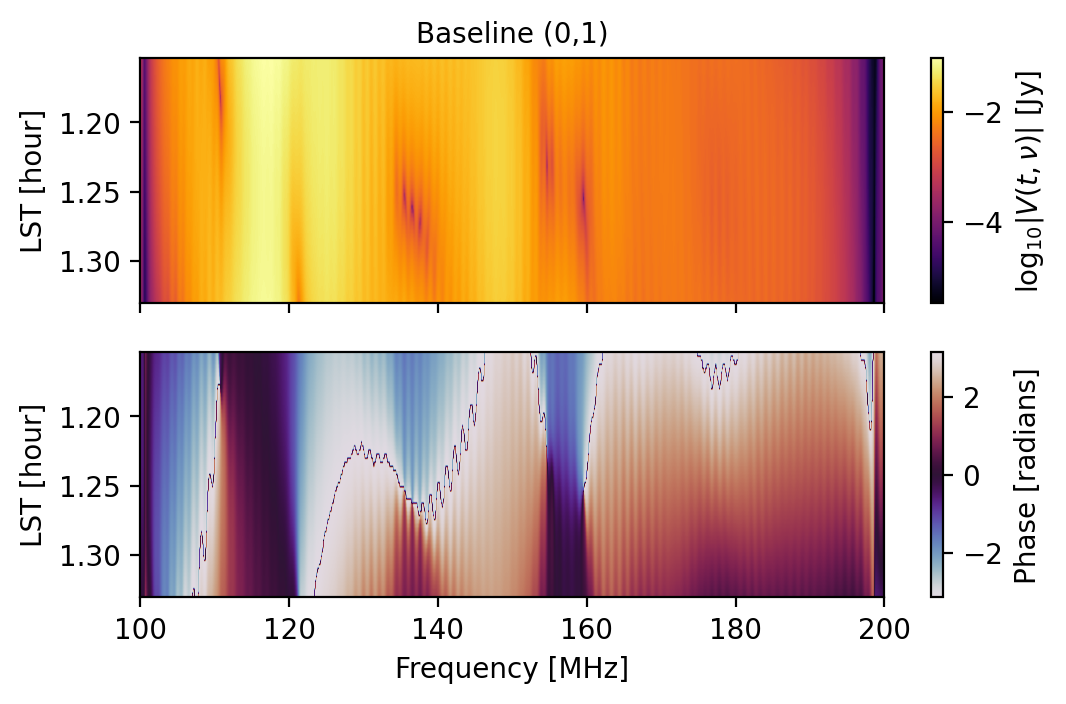

In [15]:
#Plot corrupted data
fig2 = waterfall(sim, antpairpol=(0,1,"xx"), title="Baseline (0,1)")